In [1]:
from modpath import modify_path

modify_path()

In [ ]:
import pathlib
from src import io
from src import notebook_utils as nbu
from src import inspection as insp
from src.db_config import DatasetSplit
from src.model_config import ModelVersion, TARGET

In [3]:
FIGS_DIR = pathlib.Path.cwd().parent.joinpath('figs/03/')

# Model v3.0

Final model removing the last low SHAP feature.

Removed: `arrival_delay`

In [ ]:
model_version = ModelVersion.V3_0
data = io.load_data(model_version.get_table_name(DatasetSplit.TRAIN))
test = io.load_data(model_version.get_table_name(DatasetSplit.TEST))

In [ ]:
exp_result_v3_0 = nbu.run_model(model_version, data, test, TARGET)

  0%|          | 0/10 [00:00<?, ?it/s]

In [7]:
study = exp_result_v3_0.study
best_params = {k: v for (k, v) in study.best_params.items() if k != 'classifier'}
best_params

{'n_estimators': 151,
 'max_depth': 4,
 'learning_rate': 0.011715117691438242,
 'num_leaves': 44,
 'min_child_samples': 31}

In [ ]:
output_path_v3_0 = FIGS_DIR.joinpath(f'{model_version.version_str}/')
output_path_v3_0.mkdir(parents=True, exist_ok=True)
nbu.save_figures(exp_result_v3_0, path=output_path_v3_0)
nbu.score_model(exp_result_v3_0)

,accuracy,precision,recall,f1-score,AUC,support
Test,0.910,0.911,0.910,0.910,0.964,25976
Train,0.911,0.912,0.911,0.911,0.965,103904
Test (shuffle),0.561,0.348,0.561,0.403,0.507,25976
Train (shuffle),0.567,0.580,0.567,0.411,0.522,103904


<p align="center">
    <img src="../figs/03/v3.0/shap_bar.png" width="800px" alt="bar_v3.0">
    <br>
    <em>Mean absolute SHAP values for all features of the final model.</em>
    <br></br>
    <img src="../figs/03/v3.0/shap_beeswarm.png" width="800px" alt="beeswarm_v3.0">
    <br>
    <em>Beeswarm SHAP values for all features of the final model.</em>
</p>

<div align="center">

| <center>Dataset</center> | Accuracy | Precision | Recall | F1-Score | ROC AUC |
| :--- | ---: | ---: | ---: | ---: | ---: |
| Test | 0.910 | 0.911 | 0.910 | 0.910 | 0.964 |
| Train | 0.911 | 0.912 | 0.911 | 0.911 | 0.965 |
| Test (Shuffled) | 0.561 | 0.348 | 0.561 | 0.403 | 0.507 |
| Train (Shuffled) | 0.567 | 0.580 | 0.567 | 0.411 | 0.522 |

</div>

This version of the model is working well. It has high metrics across the board and the target-shuffled AUC is close to 0.5, giving confidence that it's not significantly overfitting the training set. What we see is that the reason for travel and wifi rating features are the two frontrunners for model importance.

## Partial Dependence

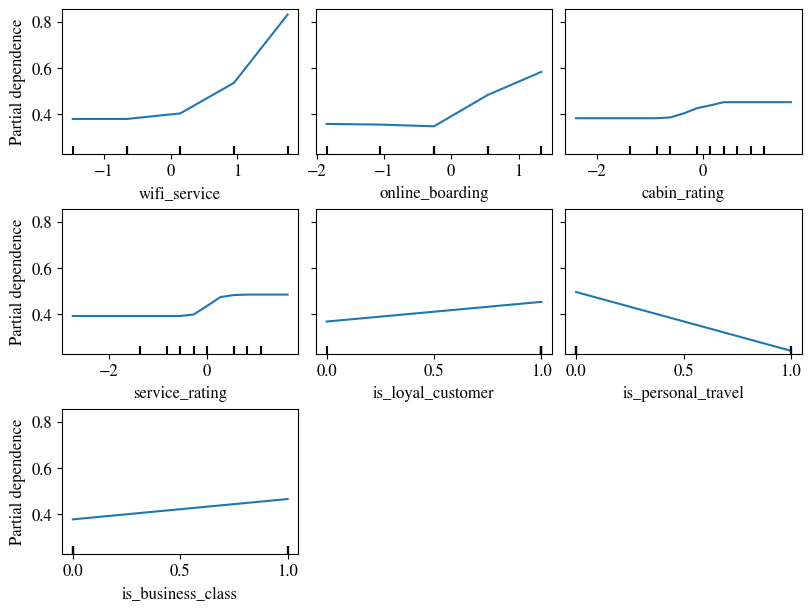

In [8]:
fig, ax = insp.plot_1d_partial_dependence(exp_result_v3_0.clf, exp_result_v3_0.X)

Observations:

1. The difference between low and high wifi ratings is very large. The jump from 4 to 5 is even larger than the jump from 1 to 4. Providing the best wifi service possible to try to get more 5 ratings could lead to a big improvement in satisfaction.

2. A passenger's reason for travel also makes a big difference on satisfaction. Passengers who are traveling for personal reasons are basically starting in a satisfaction deficit that other factors would need to make up for.

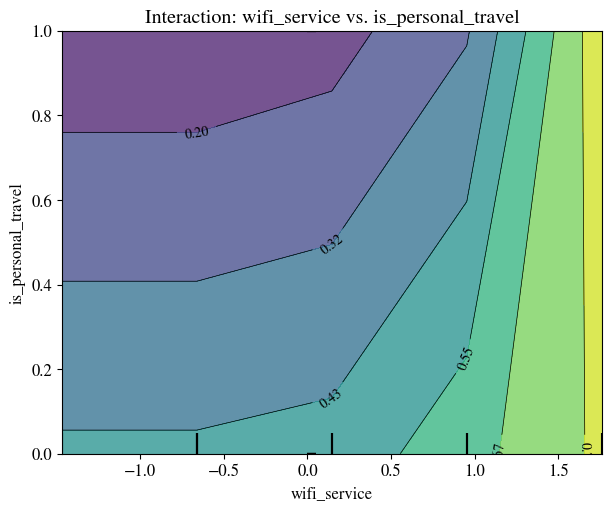

In [9]:
fig, ax = insp.plot_2d_partial_dependence(
    exp_result_v3_0.clf, exp_result_v3_0.X, 'wifi_service', 'is_personal_travel'
)

Having a moderate-to-high wifi service is generally sufficient to get passengers traveling for business reasons into a higher satisfaction probability. For passengers traveling for personal reasons, the wifi service needs to be substantially higher to get them to the same level of satisfaction probability.

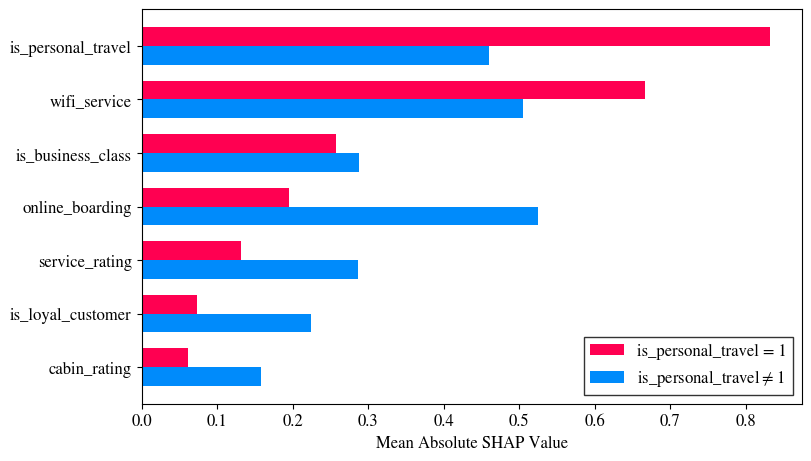

In [ ]:
nbu.plot_split_model_shap_values(exp_result_v3_0, feature='is_personal_travel', value=1)

There is a stark contrast in breakdown between passengers traveling for personal reasons and passengers traveling for business reasons. Personal travelers are dominated by the fact that they are traveling for personal reasons. Other factors have little impact on their satisfaction outside of the wifi service. Even moving them to business class has relatively low impact. Business travelers have a much more broad set of impacting factors. While they also care about the wifi service, factors like online boarding and the general cabin and service ratings also have a fair impact on their satisfaction.

Ultimately, it seems like passenger satisfaction likely comes down to money and the value of that money. Business travelers are likely not paying their own airfare, whereas personal travelers are paying hundreds of dollars for an experience they don't see as great value. There's likely no amount of improvement in cleanliness or inflight service that will move the needle for these passengers. It would take something that increases the value of the price paid to fly to improve their satisfaction.